# Oxford Pets adversarial representations: results explained
## A visual reading of the 15-epoch reference run

**Completed local run · 15 epoch(s) · 1380 optimizer updates per arm ·
configuration `9e9727fe7a442e0e…`**

This companion is built from saved machine-readable experiment evidence, registered
dataset metadata, and verified aggregate figures. It can be read without running any cell.
It performs no training, inference, attack, download, or public action, and it contains
no original pet photographs.

**Bottom line:** the registered representation criterion passed. Under PGD-20×5,
robust accuracy was 0.00% for standard fine-tuning and
20.68% for PGD-5 fine-tuning. The representation result
coincided with partial—not complete—robust recognition and a substantial clean-accuracy cost.

## 1. What was actually run

| Control | Recorded value |
| --- | --- |
| Dataset | Oxford-IIIT Pet · 37 breeds |
| Training / calibration / official test | 2,944 / 736 / 3,669 images |
| Training budget | 15 epoch(s) · 1380 updates per arm |
| Standard summed epoch time | 8.0 minutes (479.3 seconds) |
| PGD-5 summed epoch time | 26.6 minutes (1597.3 seconds) |
| Attack subset | 740 images · 20 per breed · FGSM and PGD-20×5 |
| Feature analyzed | 512-D vector after ResNet average pooling, before its head |

## 2. Exploratory data analysis

EDA checks what the model receives before interpreting accuracy or representations. It uses the registered split metadata and stored image headers; no original pet photograph is embedded.

| Dataset property | Observed value |
| --- | --- |
| Registered images | 7,349 |
| Prediction classes | 37 breeds |
| Breed families | 12 cat breeds · 25 dog breeds |
| Training / calibration / test | 2,944 / 736 / 3,669 |
| Median stored width × height | 500 × 375 px |
| Aspect ratio, median [IQR] | 1.33 [0.75, 1.49] |
| Portrait / square / landscape | 32.1% / 1.6% / 66.3% |

| Partition and species balance | Per-breed balance |
|---|---|
| 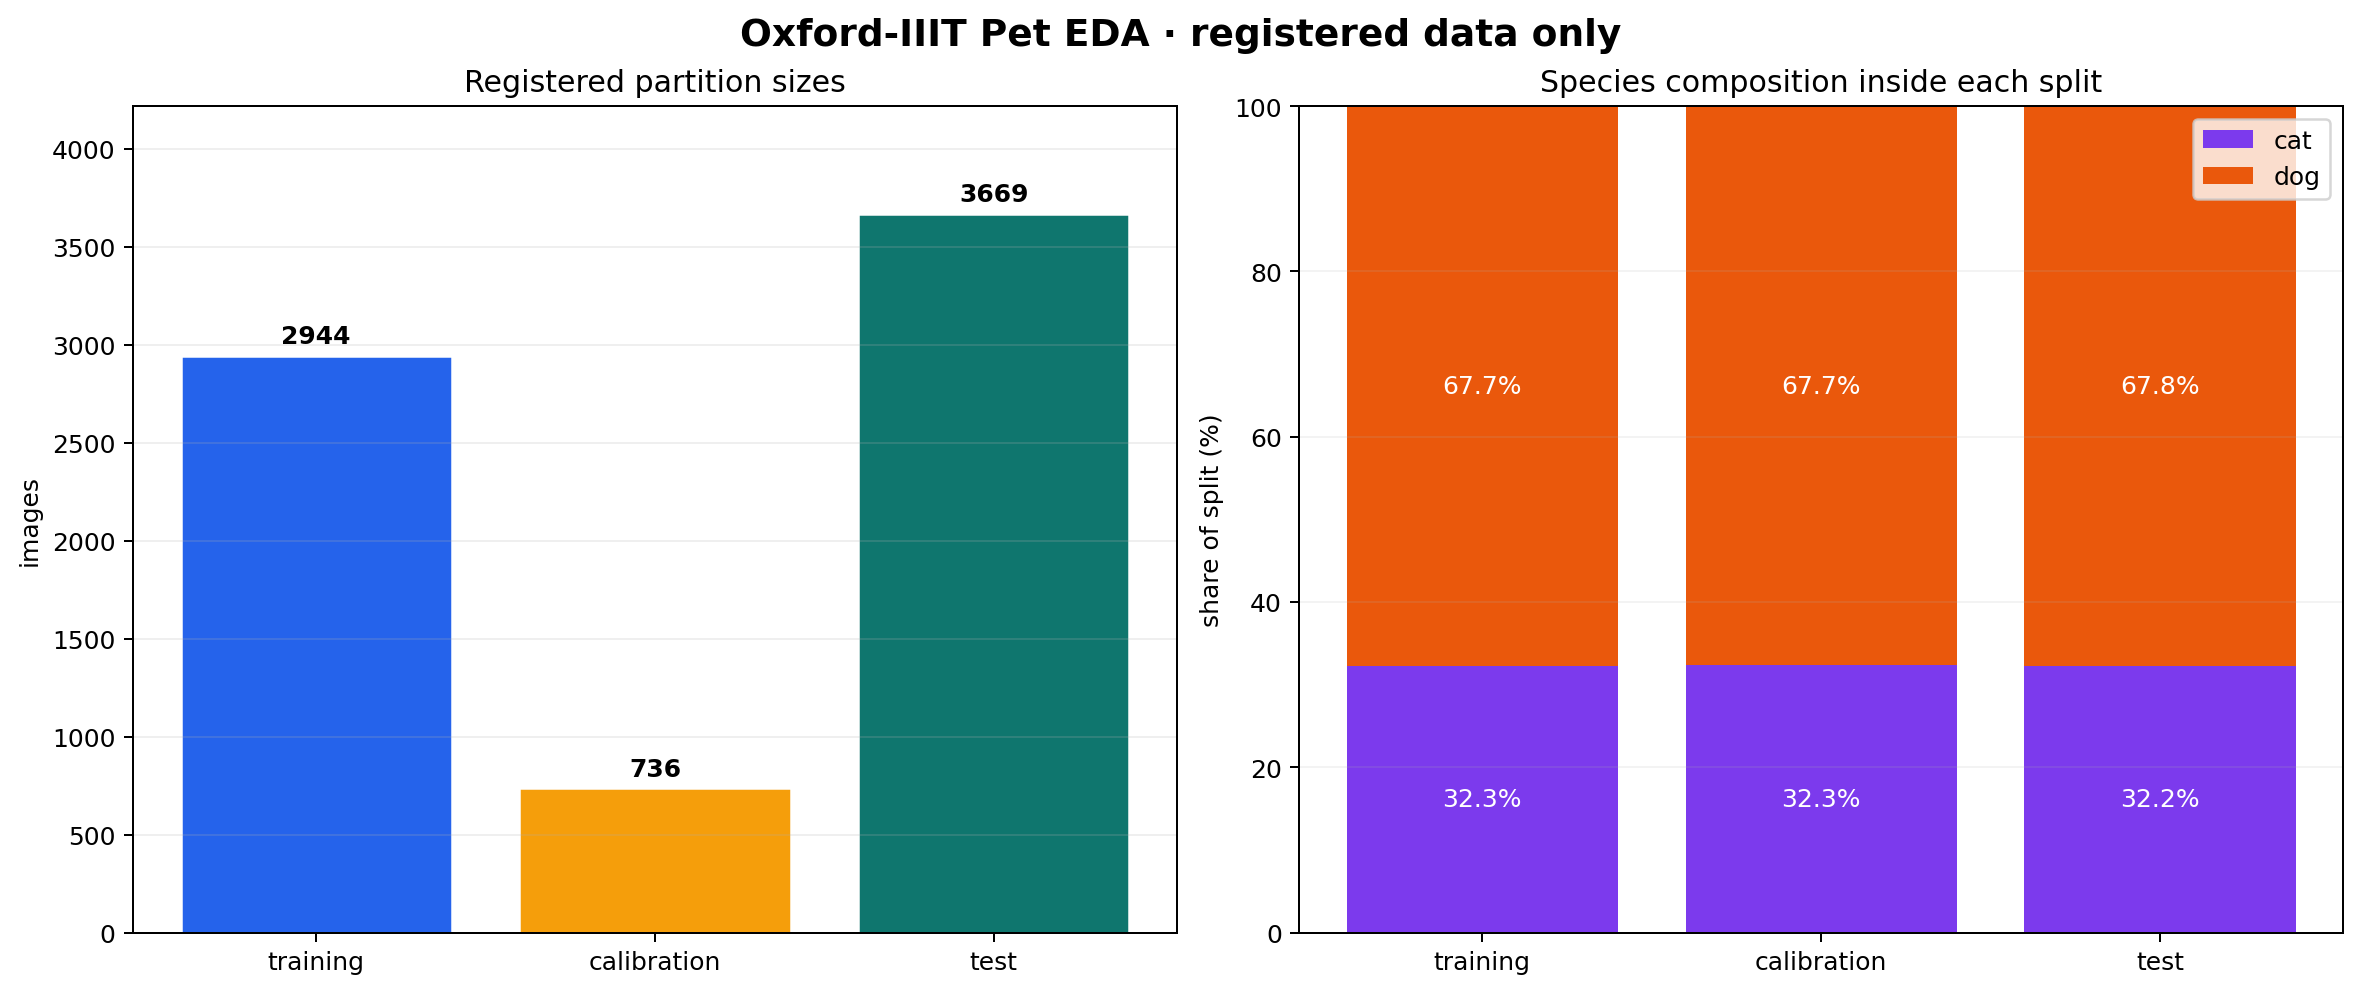 | 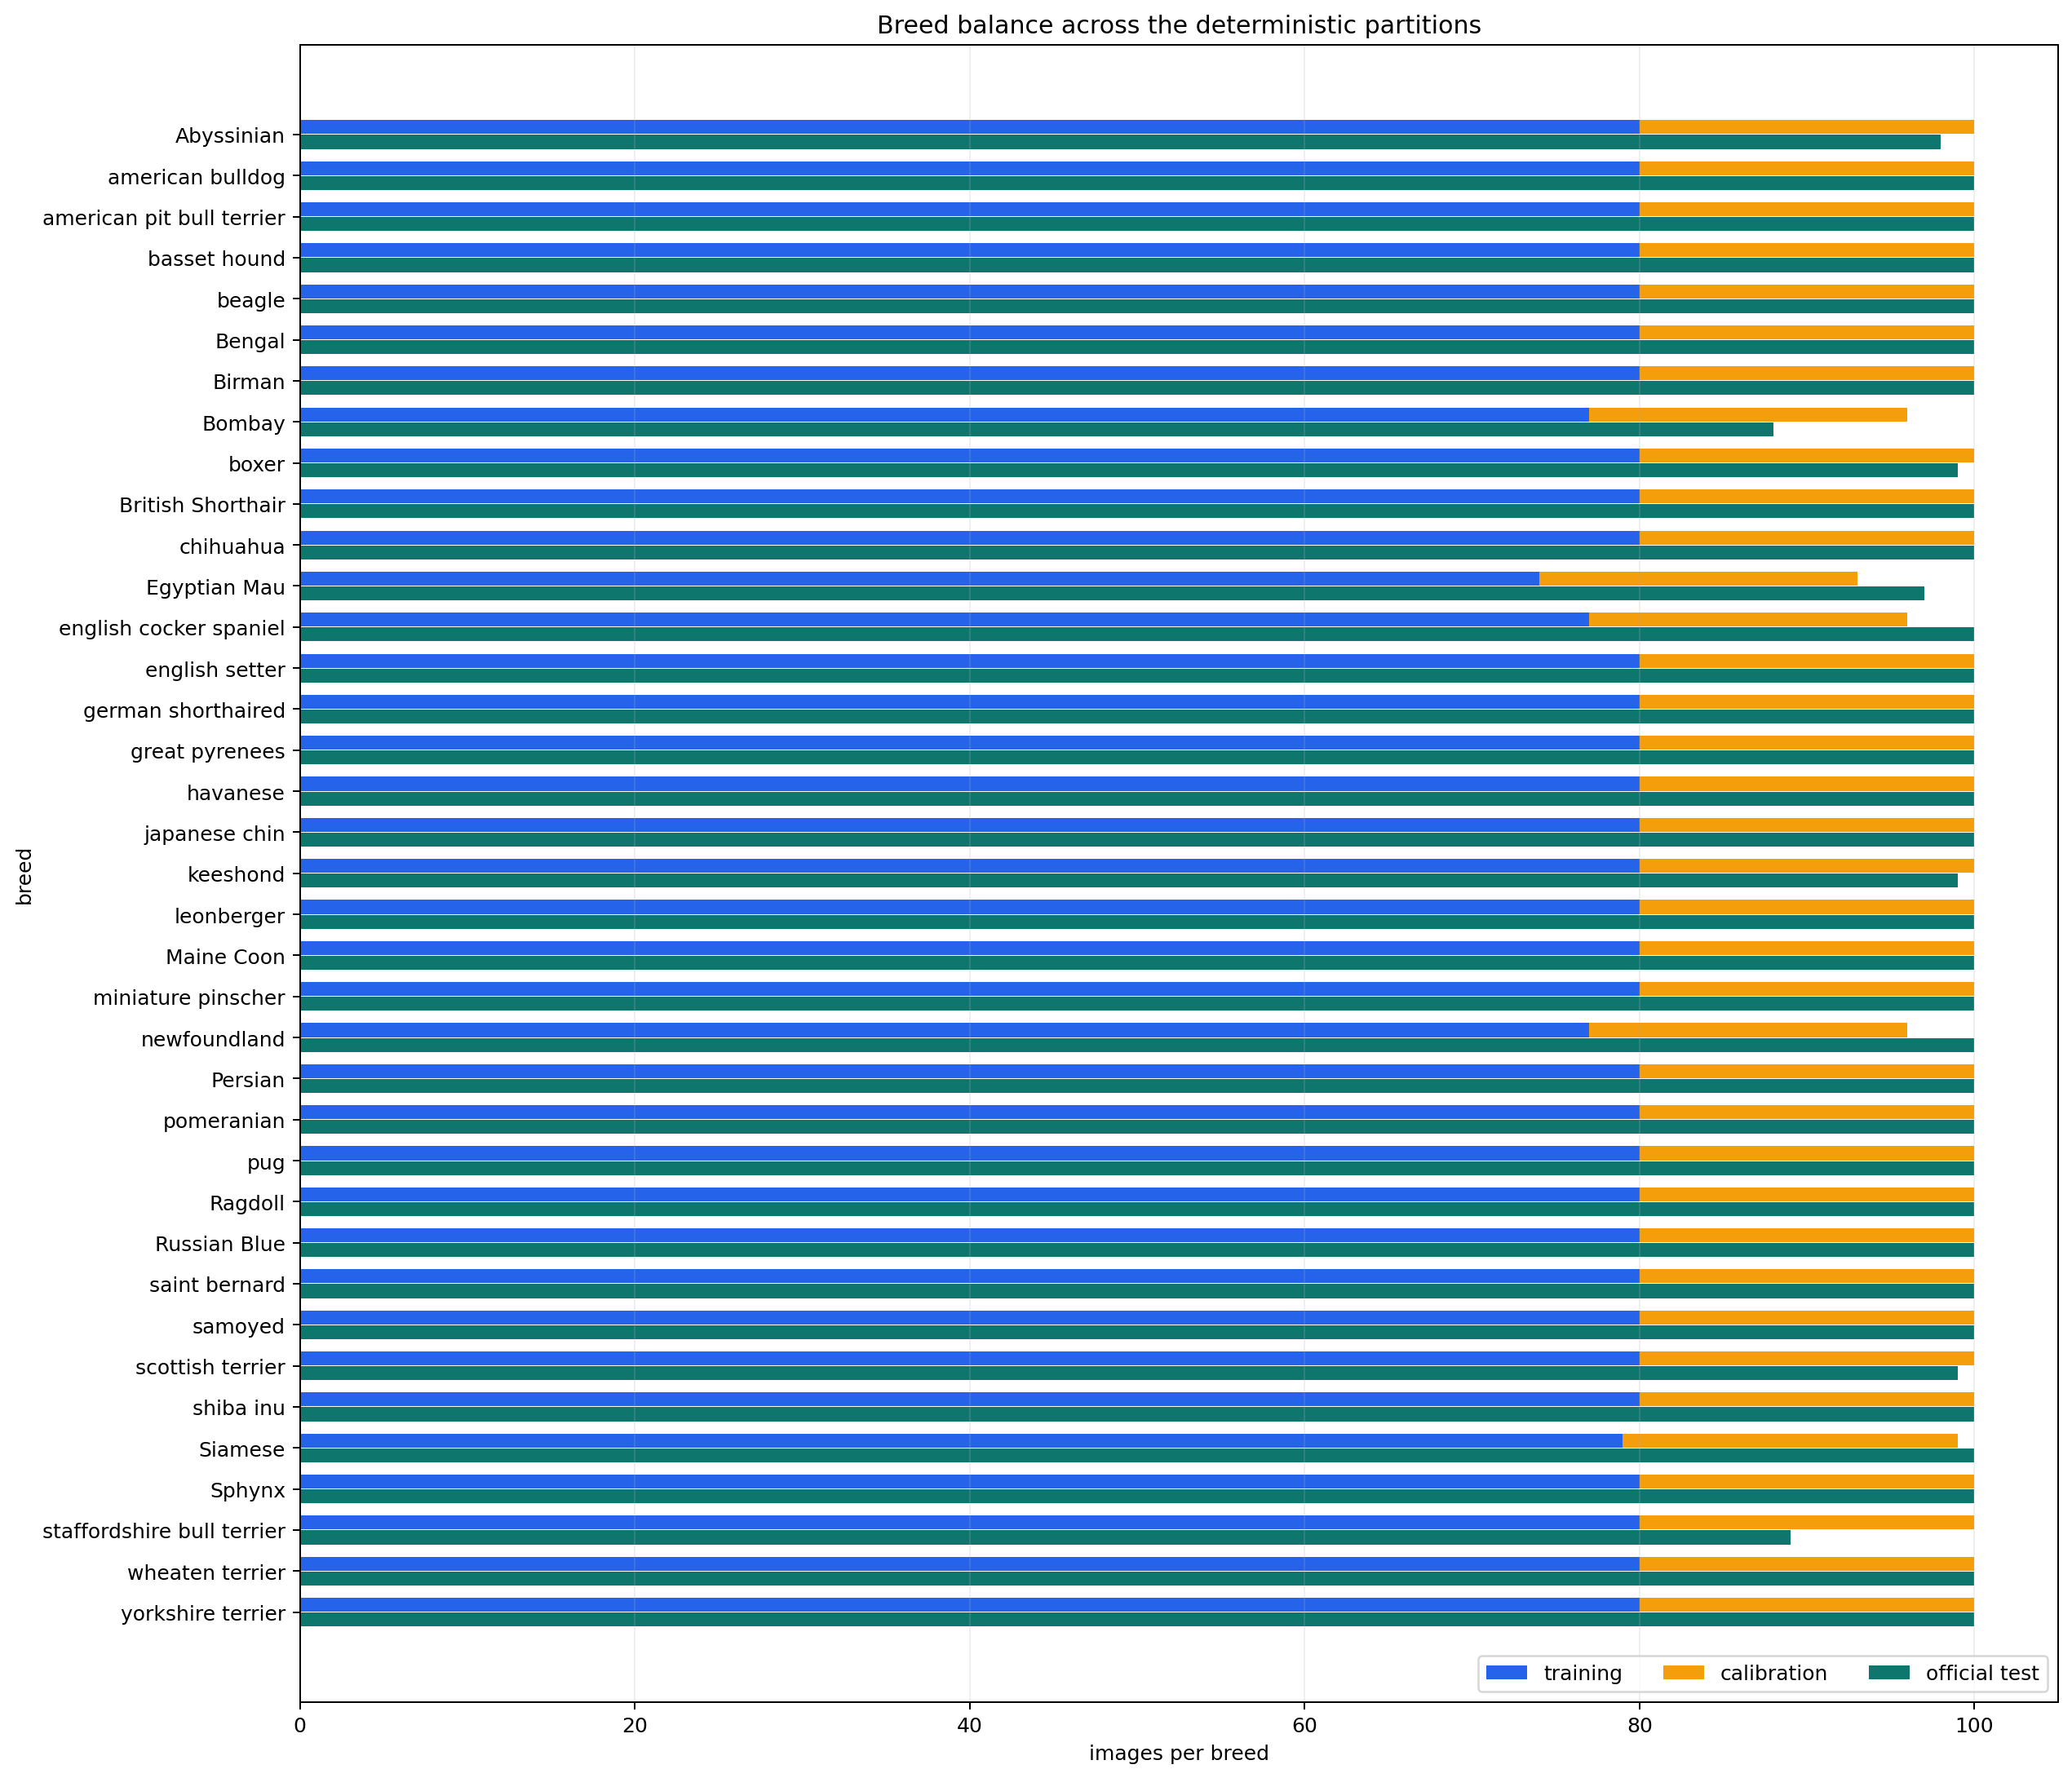 |

### Stored image dimensions and aspect ratios

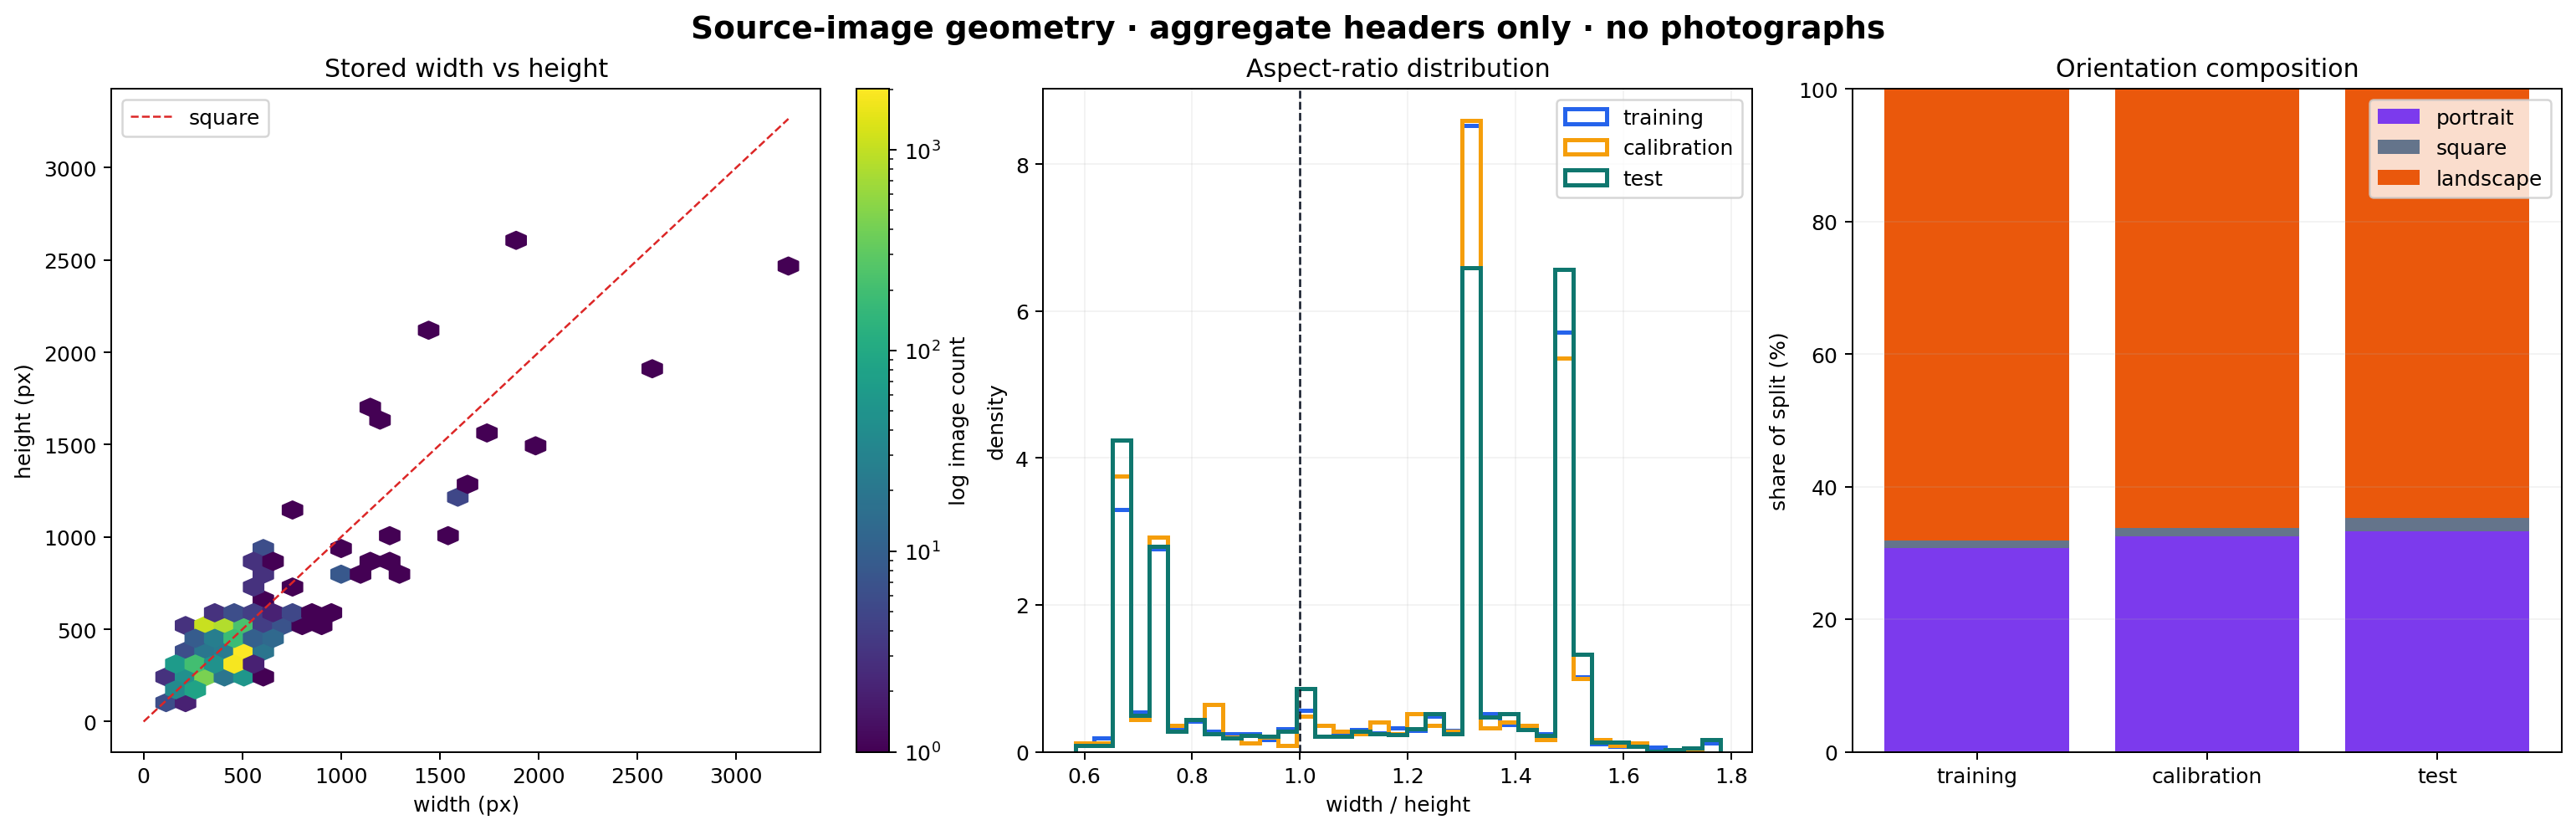

**What this changes:** the official test set is slightly smaller than trainval, but every breed remains represented. Cats and dogs are not balanced as breed families, so species coloring is contextual only; it is not a second prediction task. The varied source geometry also explains why the registered resize/crop transform is necessary.

## 3. Prediction results before interpreting embeddings

| Metric | Standard | PGD-trained |
| --- | --- | --- |
| Clean accuracy · full official test | 89.15% | 72.91% |
| Clean accuracy · 740-image attack subset | 87.97% | 72.57% |
| FGSM robust accuracy · attack subset | 2.84% | 31.08% |
| PGD-20×5 robust accuracy · attack subset | 0.00% | 20.68% |

**Observation:** PGD-5 training changed full-test clean accuracy by **-16.24 percentage points** and PGD-20×5 robust accuracy by **+20.68 percentage points** relative to standard fine-tuning. Attack success among clean-correct samples was 100.00% versus 71.51%. The standard model also had higher absolute accuracy on every registered corruption. **Interpretation:** the adversarial arm traded clean and corruption accuracy for partial resistance to the registered bounded attack; it did not establish general robustness.

## 4. The registered 512-D representation test

| Original-feature metric | Standard | PGD-trained |
| --- | --- | --- |
| Median cosine drift ↓ | 0.4531 | 0.0378 |
| Median relative-L2 drift ↓ | 2.8832 | 0.2833 |
| Clean 5-NN accuracy ↑ | 88.65% | 70.41% |
| PGD-20×5 5-NN accuracy ↑ | 0.00% | 27.57% |
| PGD-20×5 5-NN breed retention ↑ | 0.11% | 25.62% |
| Clean→PGD linear CKA ↑ | 0.1669 | 0.8627 |

The adversarial-minus-standard median-drift difference was **-0.4154** with 95% interval `[-0.4234, -0.4089]`. The retention difference was **25.51 percentage points** with interval `[23.54, 27.62]`. Both registered interval signs met the conjunctive decision rule.

**Practical check:** PGD-trained neighbour retention was 25.62%; a balanced 37-class chance reference is approximately 2.70%. Its PGD-20×5 five-NN accuracy was 27.57%, alongside model robust accuracy of 20.68%. The geometry retained useful class information, but neither metric approached the model's clean performance.

## 5. Original 512-D geometry

The standard feature drift is centered near 0.453, while the PGD-trained drift is centered near 0.038. Standard five-neighbour breed retention is almost zero across breeds; PGD-trained retention is higher but varies substantially by class. These are the decision-useful original-space measurements, not projection scores.

| Standard fine-tuning | PGD-5 fine-tuning |
|---|---|
| 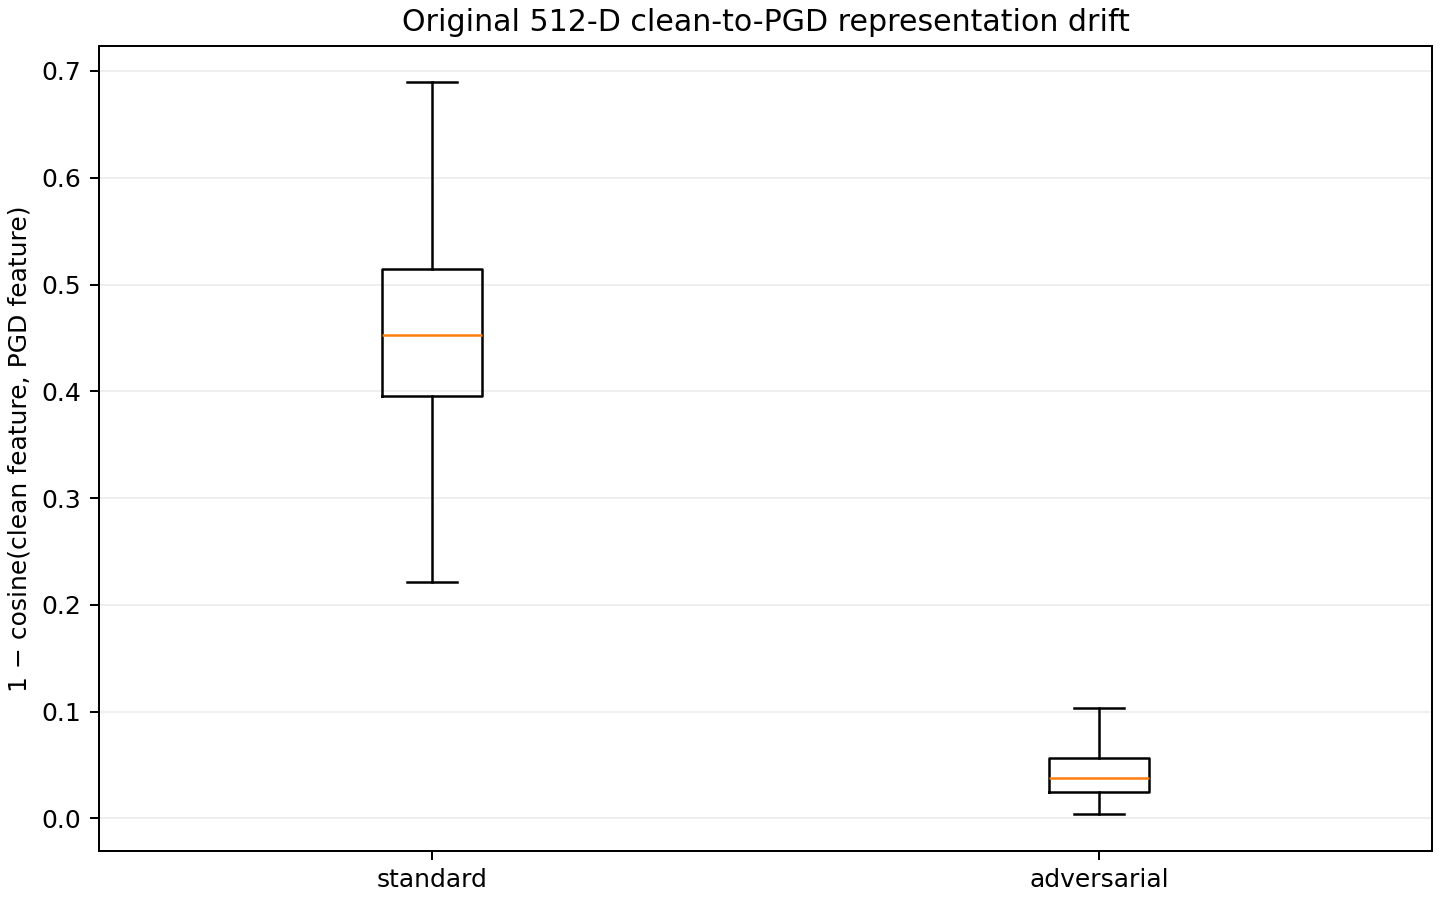 | 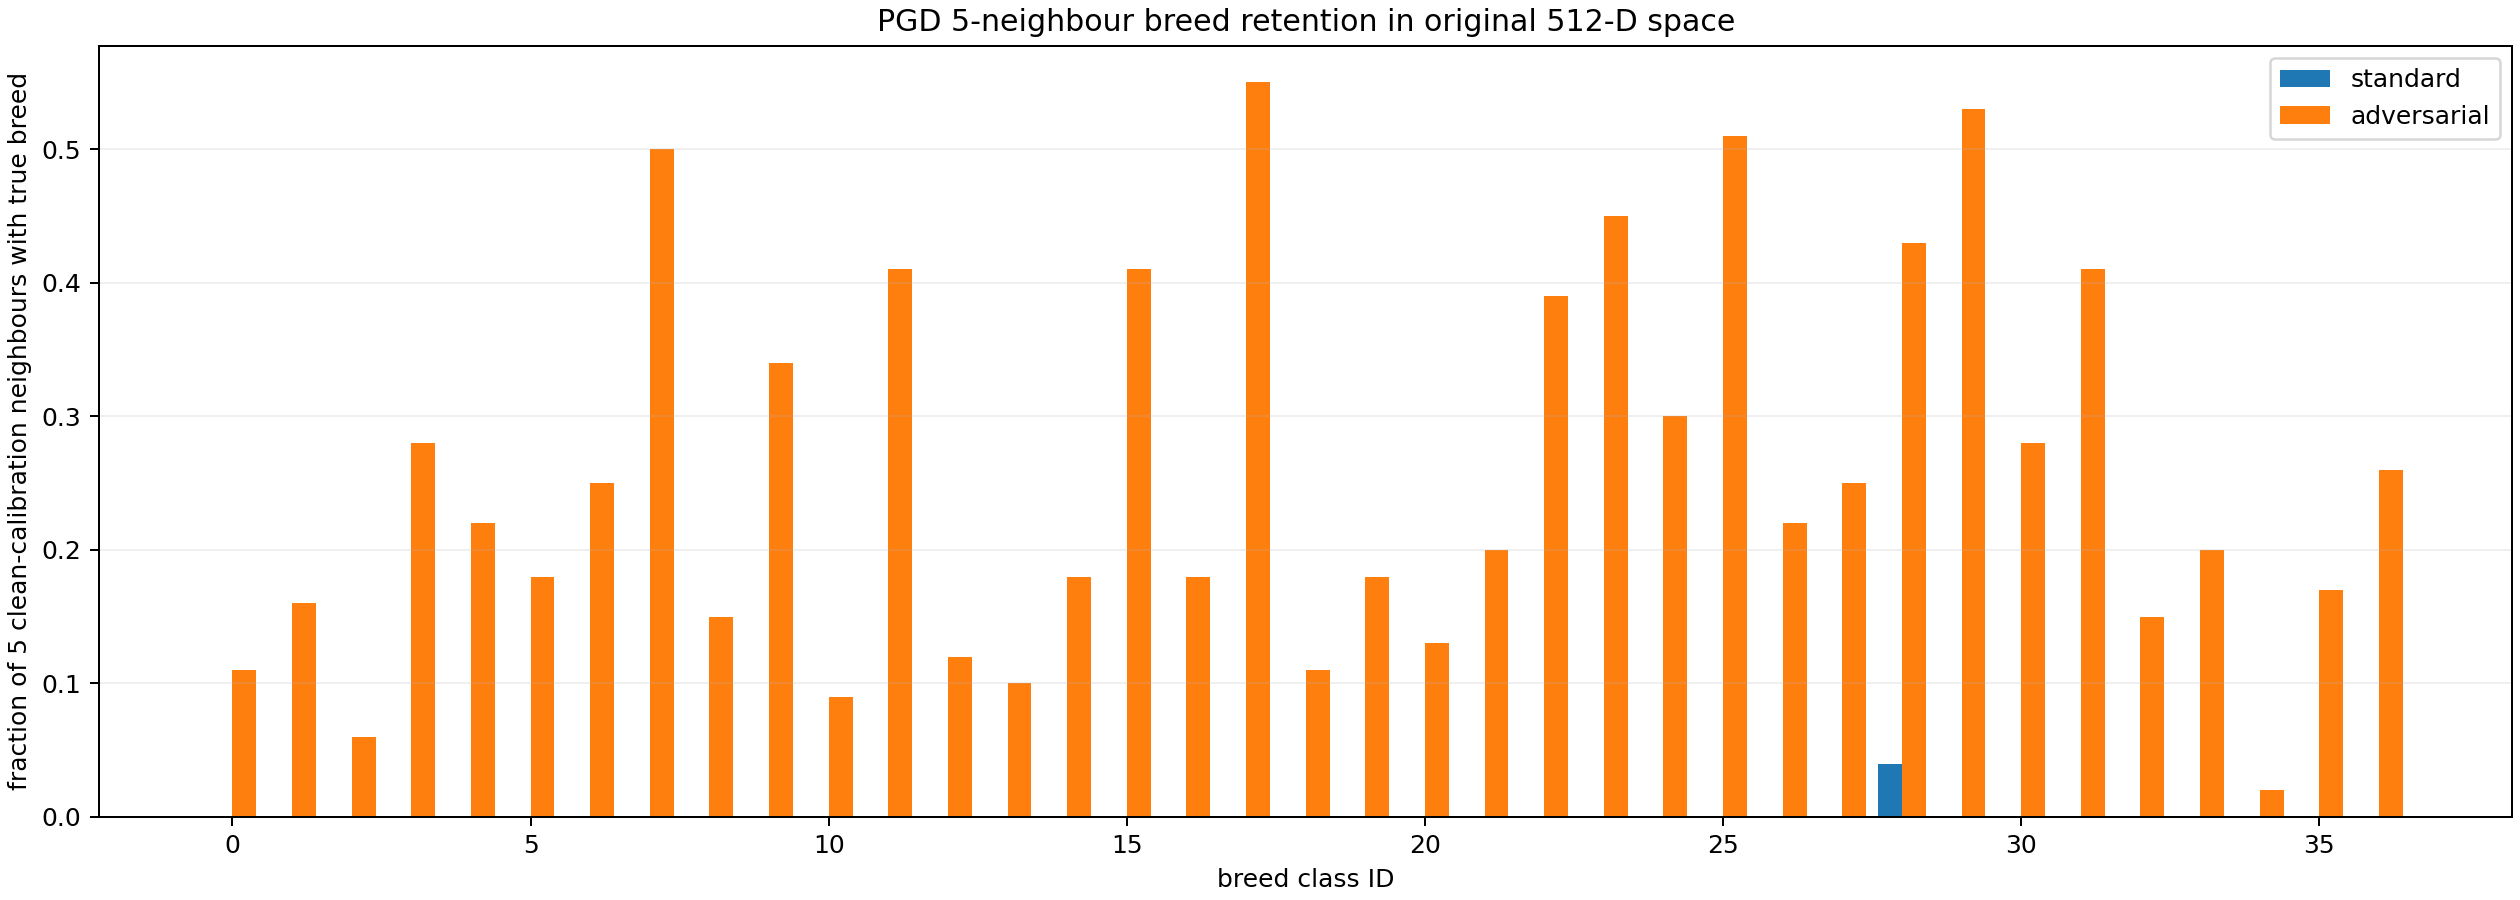 |


## 6. PCA: dominant linear variance

The first two clean-calibration PCs explain only 16.05% of standard variance and 16.66% of PGD-trained variance. The standard attacked cloud moves to a much wider, differently located region; the PGD-trained clean and attacked layouts occupy more similar ranges. Read only within each model—the two PCA bases are independent.

| Standard fine-tuning | PGD-5 fine-tuning |
|---|---|
| 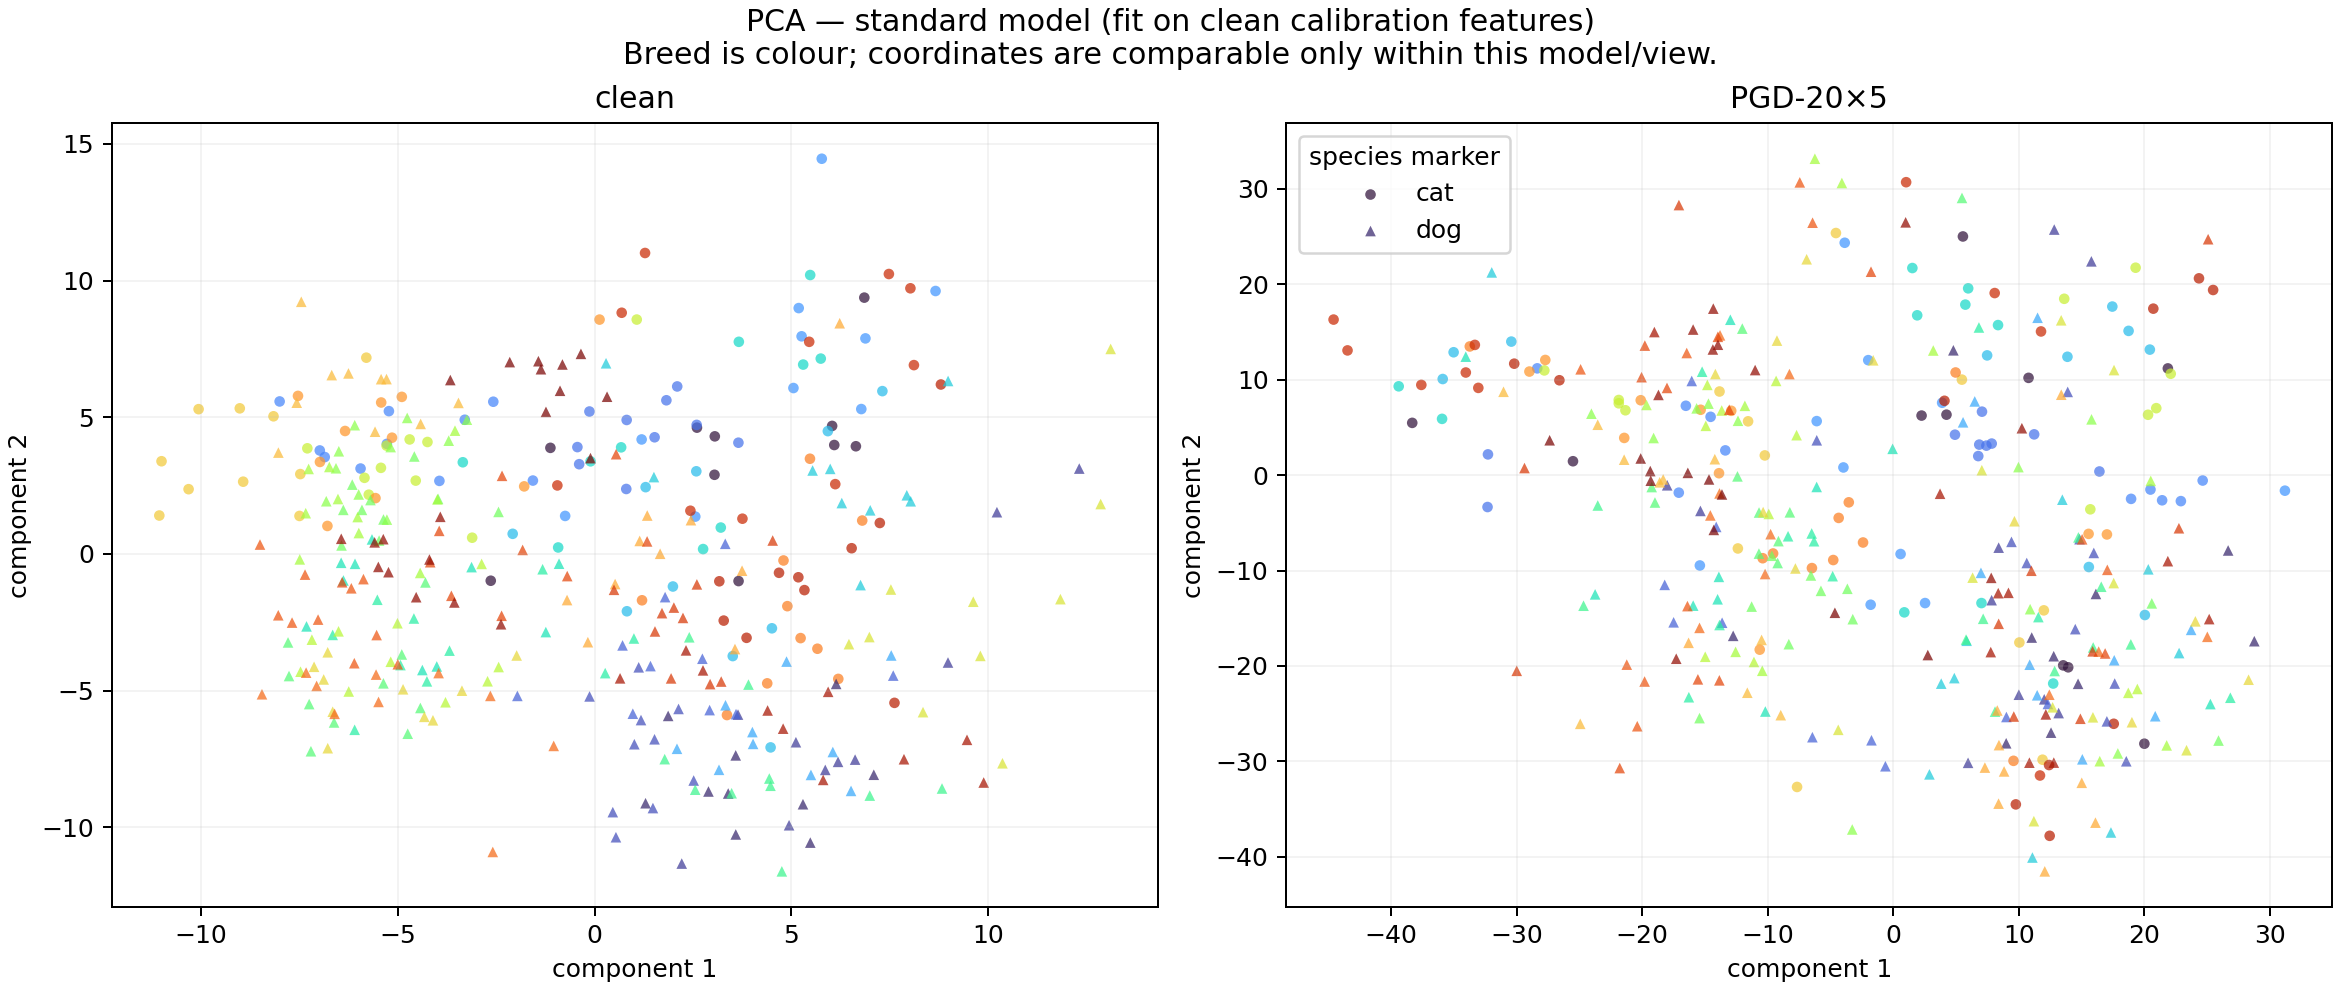 | 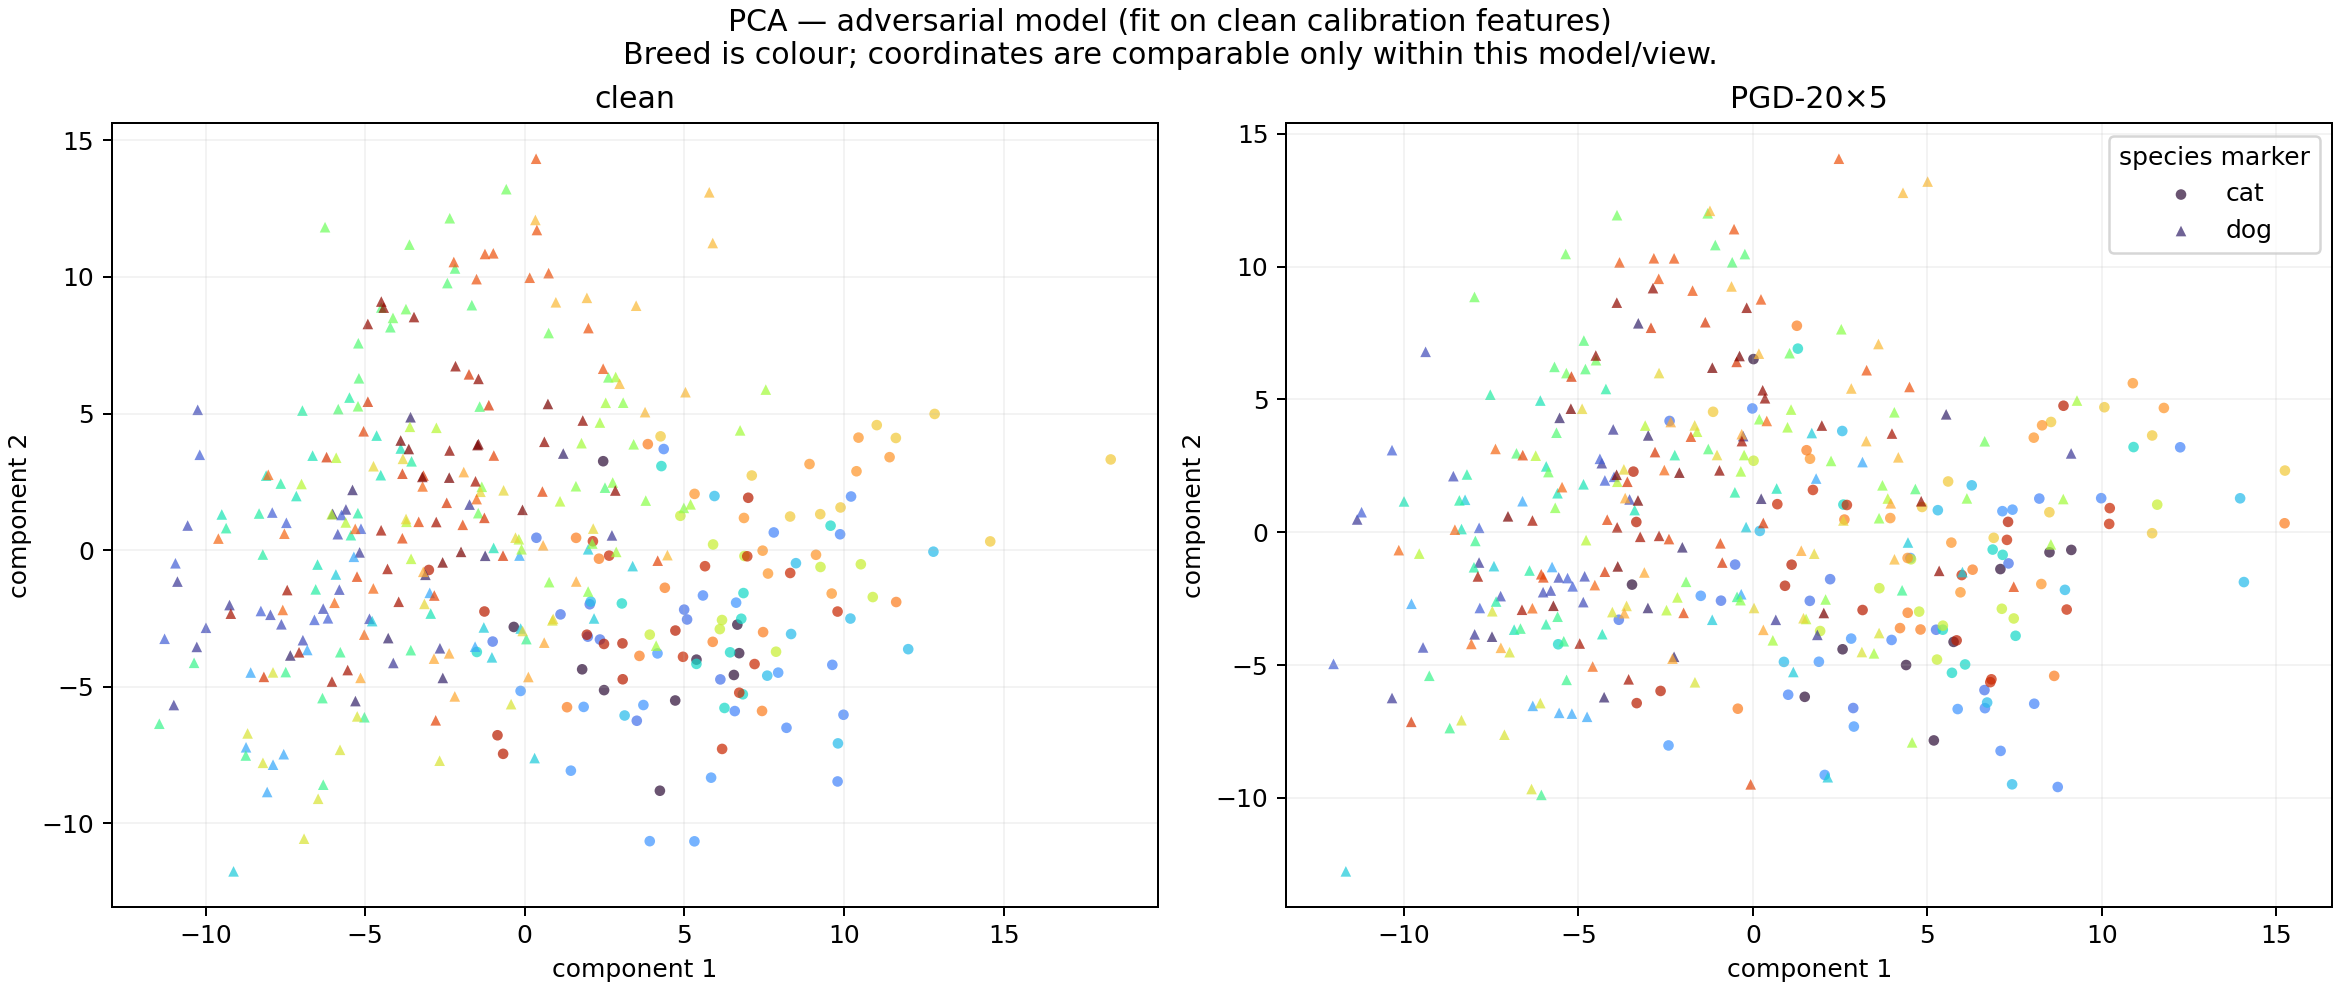 |


## 7. t-SNE: local relationships in a joint sample

For the standard model, clean breed-local groups become tight mixed-colour attacked islands. The PGD-trained clean and attacked samples occupy broadly similar manifold shapes, although breed mixing remains. t-SNE was fitted jointly within each model and emphasizes local neighbourhoods; island spacing and global axes are not evidence.

| Standard fine-tuning | PGD-5 fine-tuning |
|---|---|
| 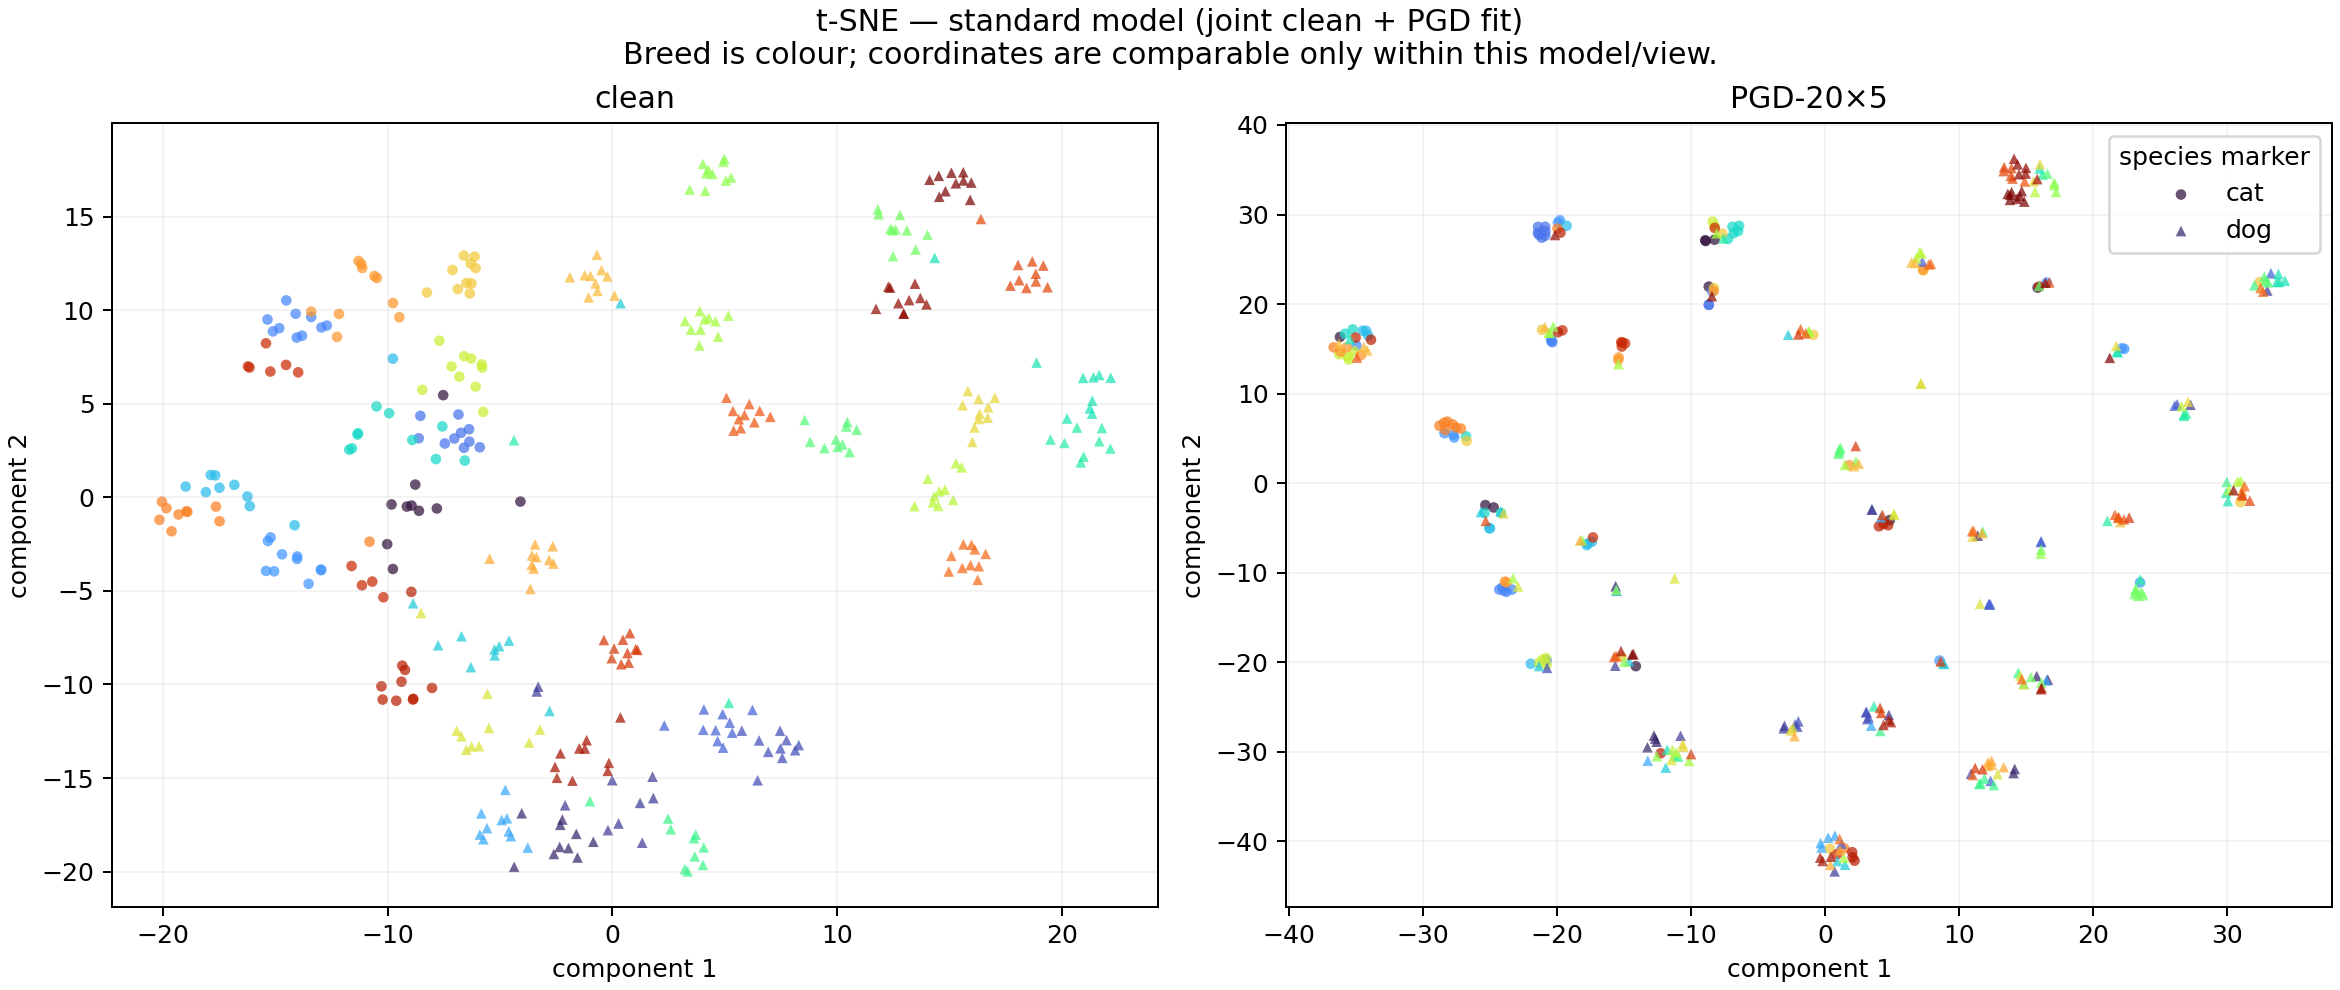 | 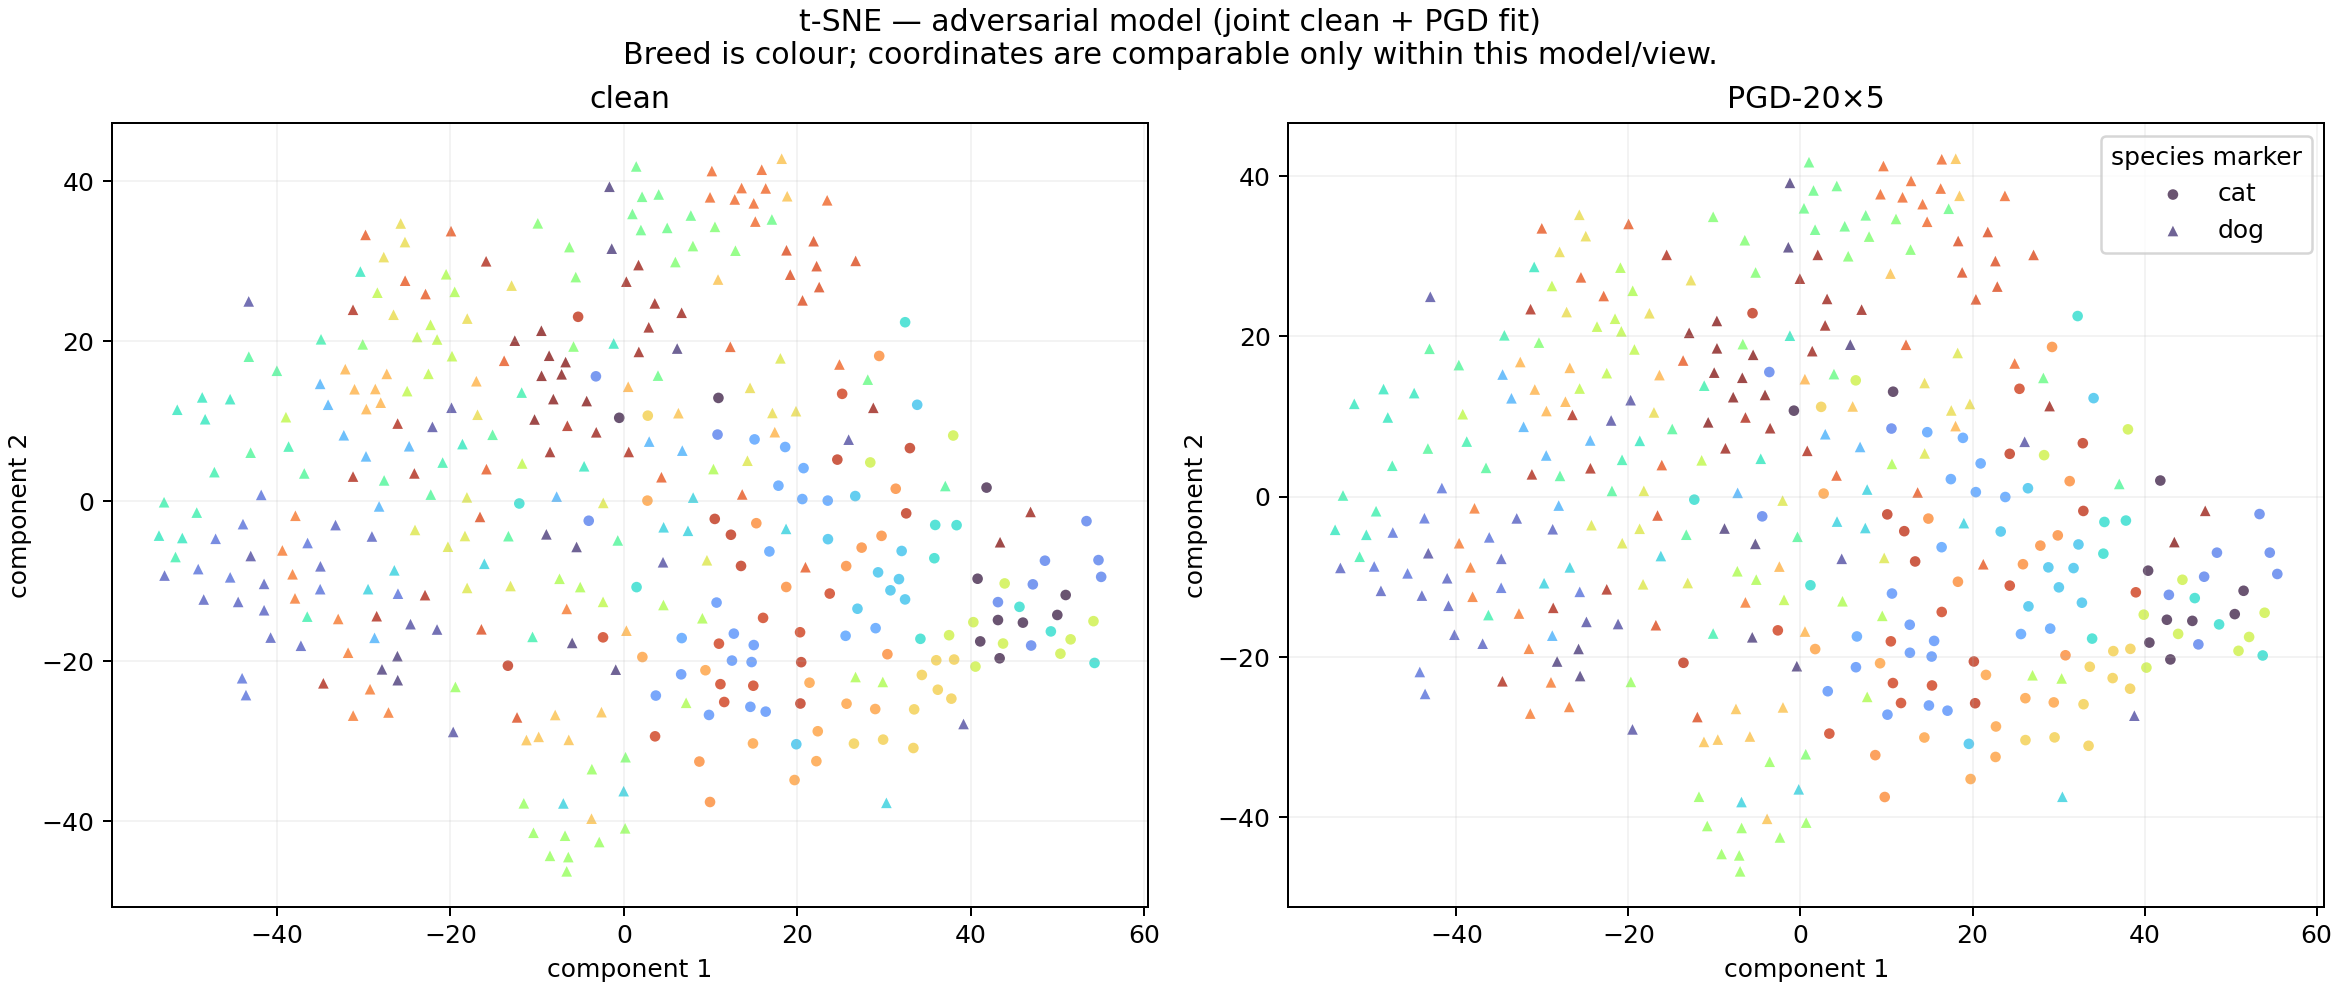 |


## 8. UMAP: transformed calibration neighbourhoods

The standard model's attacked samples transform into compact mixed-breed packets that differ sharply from its clean graph. The PGD-trained clean and attacked views retain more of the same broad layout, with visible class overlap. UMAP uses a clean-calibration reference graph and explains neighbourhood change; it does not validate robustness.

| Standard fine-tuning | PGD-5 fine-tuning |
|---|---|
| 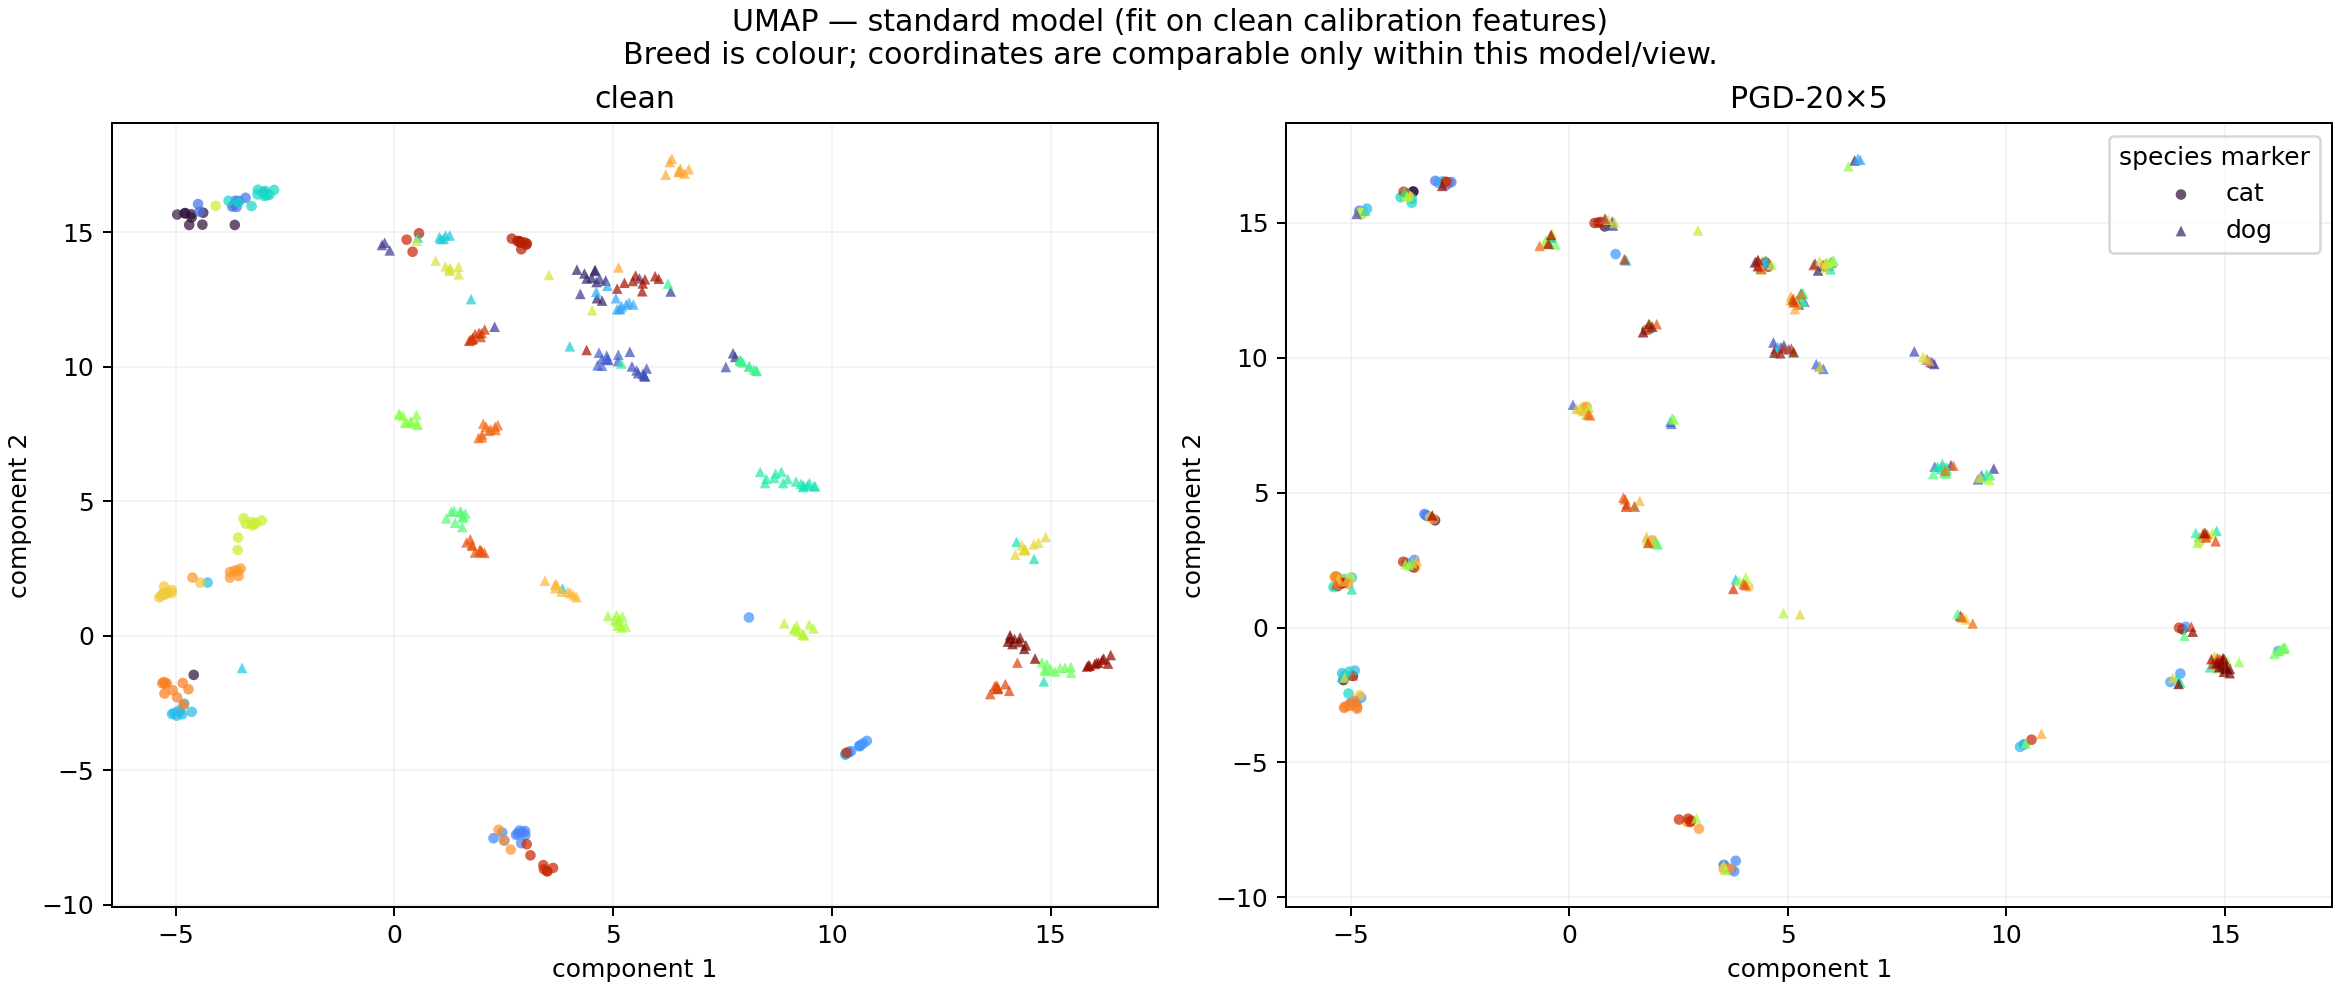 | 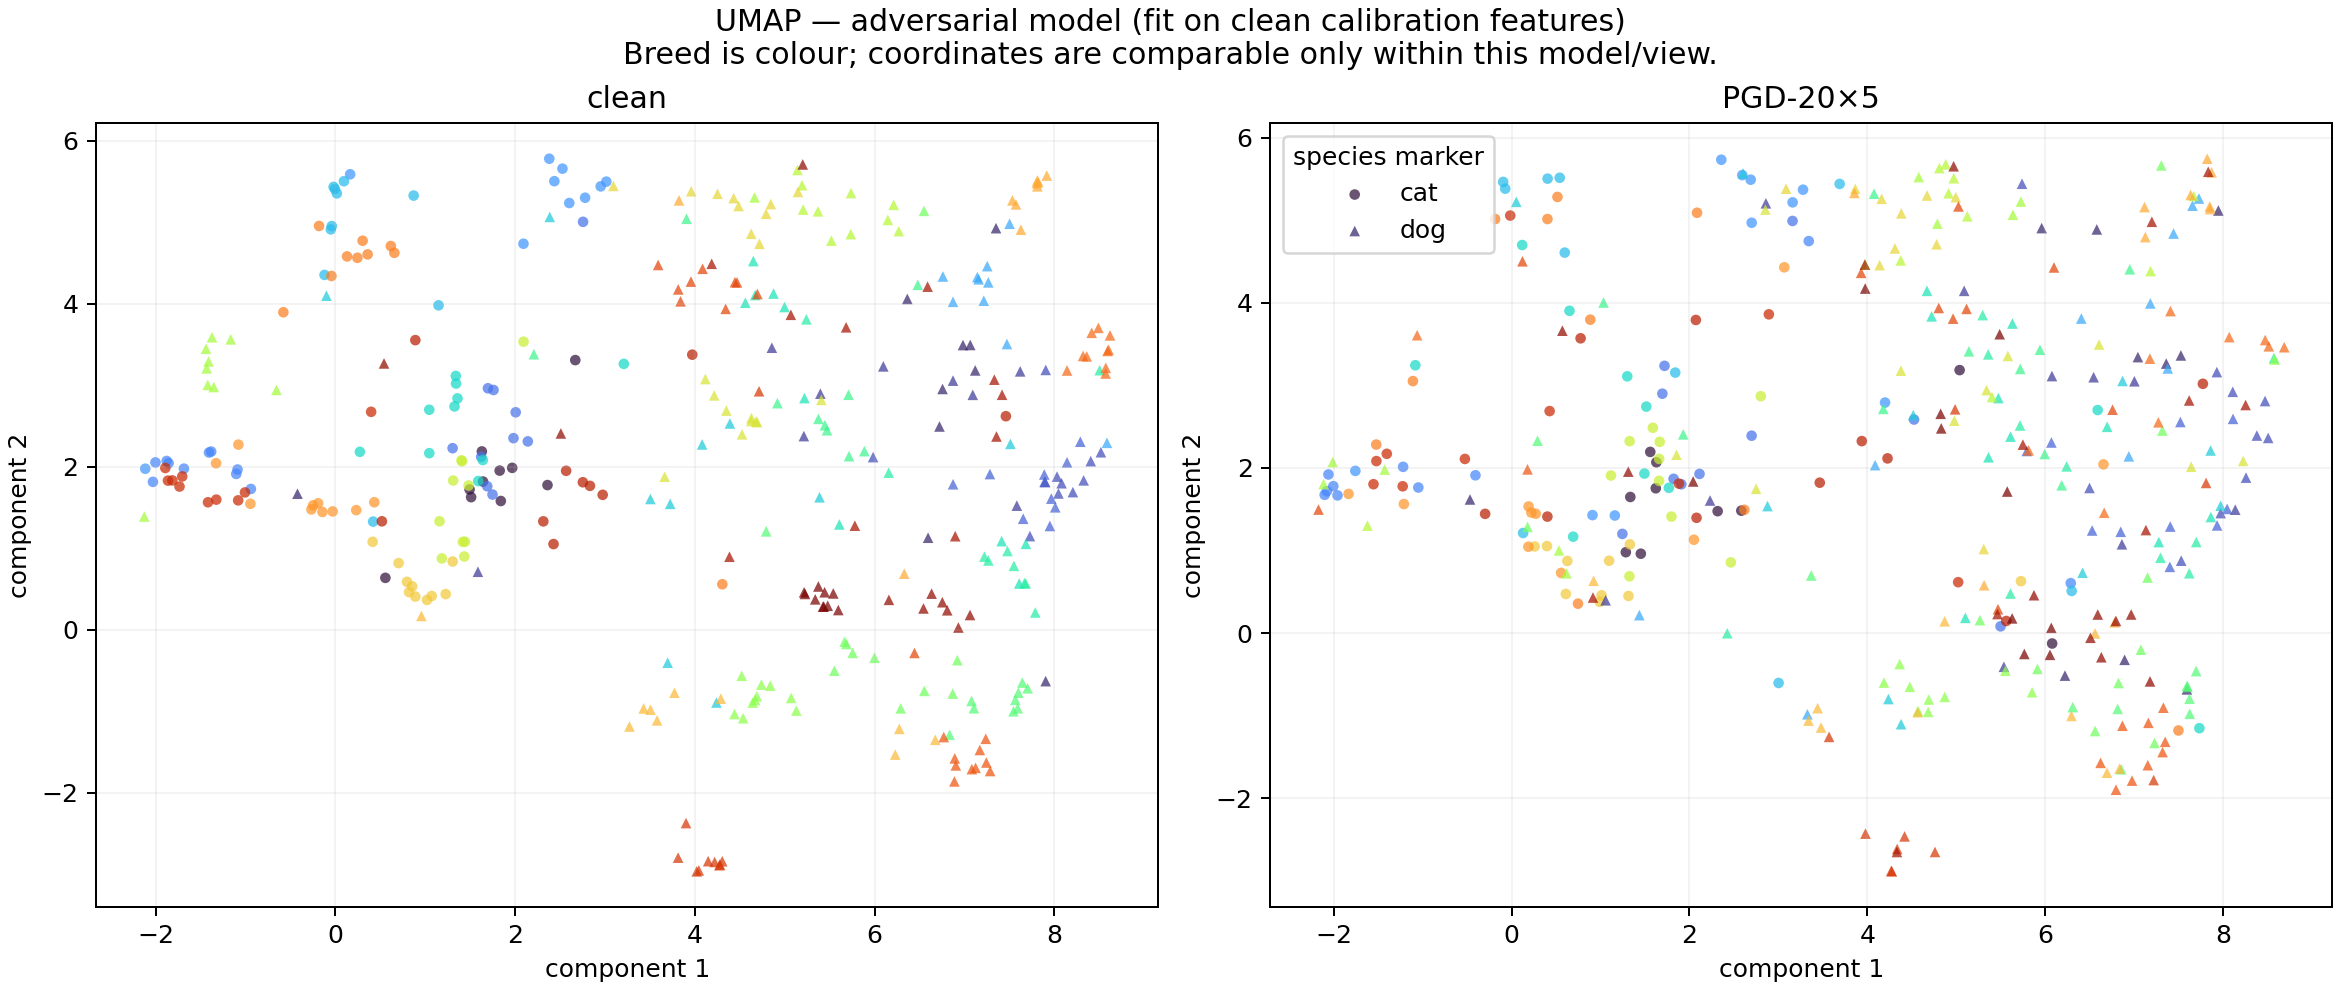 |


## 9. Difficult-pair classifier slices

The registered difficult pair is Bengal (class 5) and Egyptian_Mau (class 11). In both panels, the exact two-logit equality line lies away from most displayed points. That is evidence about this two-PC slice: the classifier can depend strongly on the 510 hidden feature directions. It is not a complete 37-class or image-space decision boundary.

| Standard fine-tuning | PGD-5 fine-tuning |
|---|---|
| 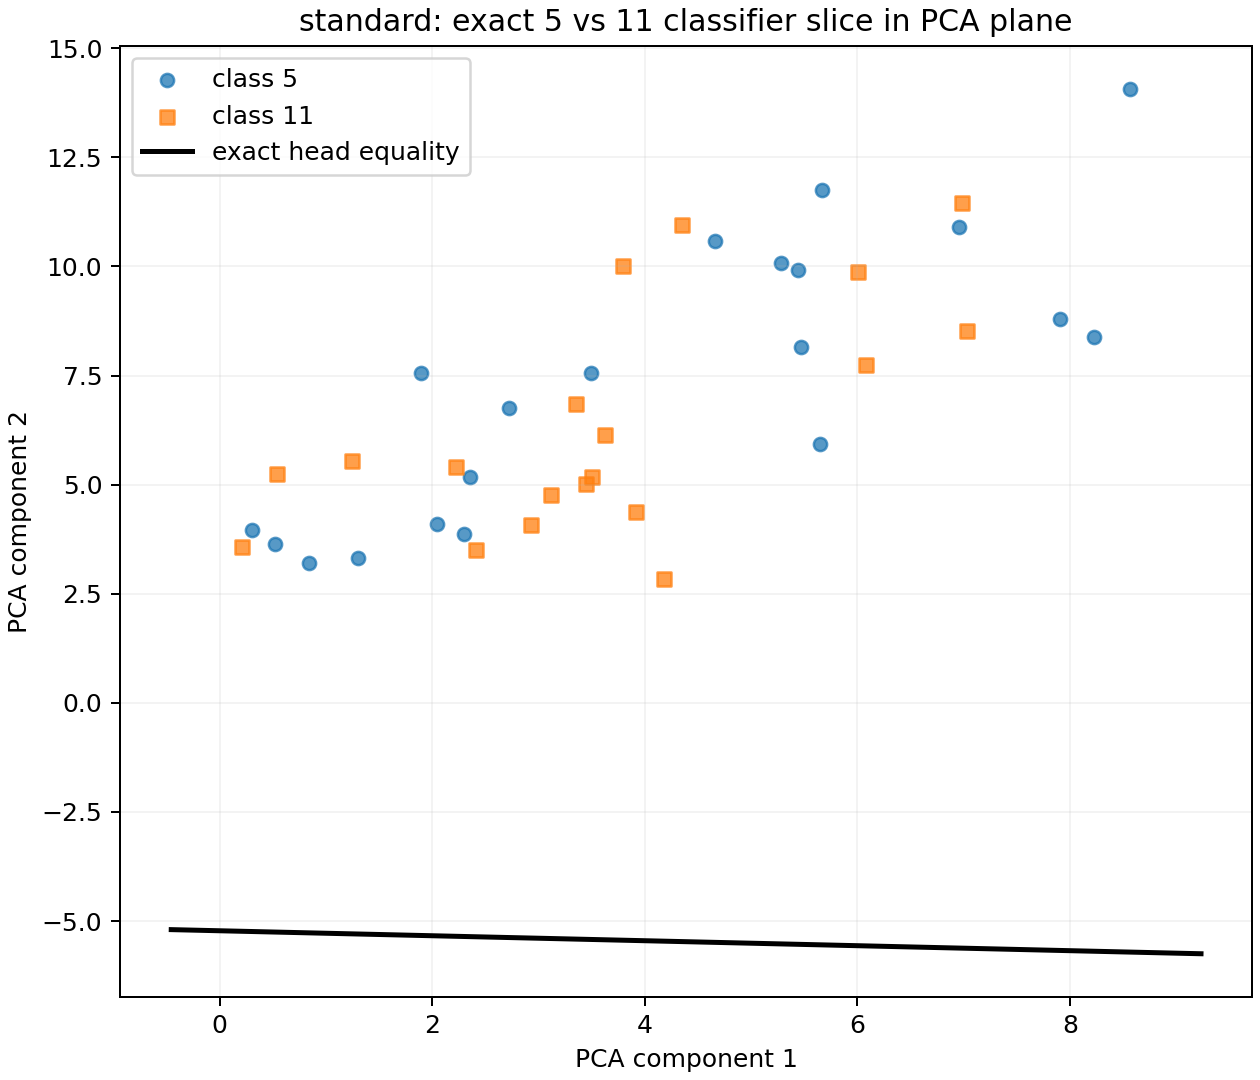 | 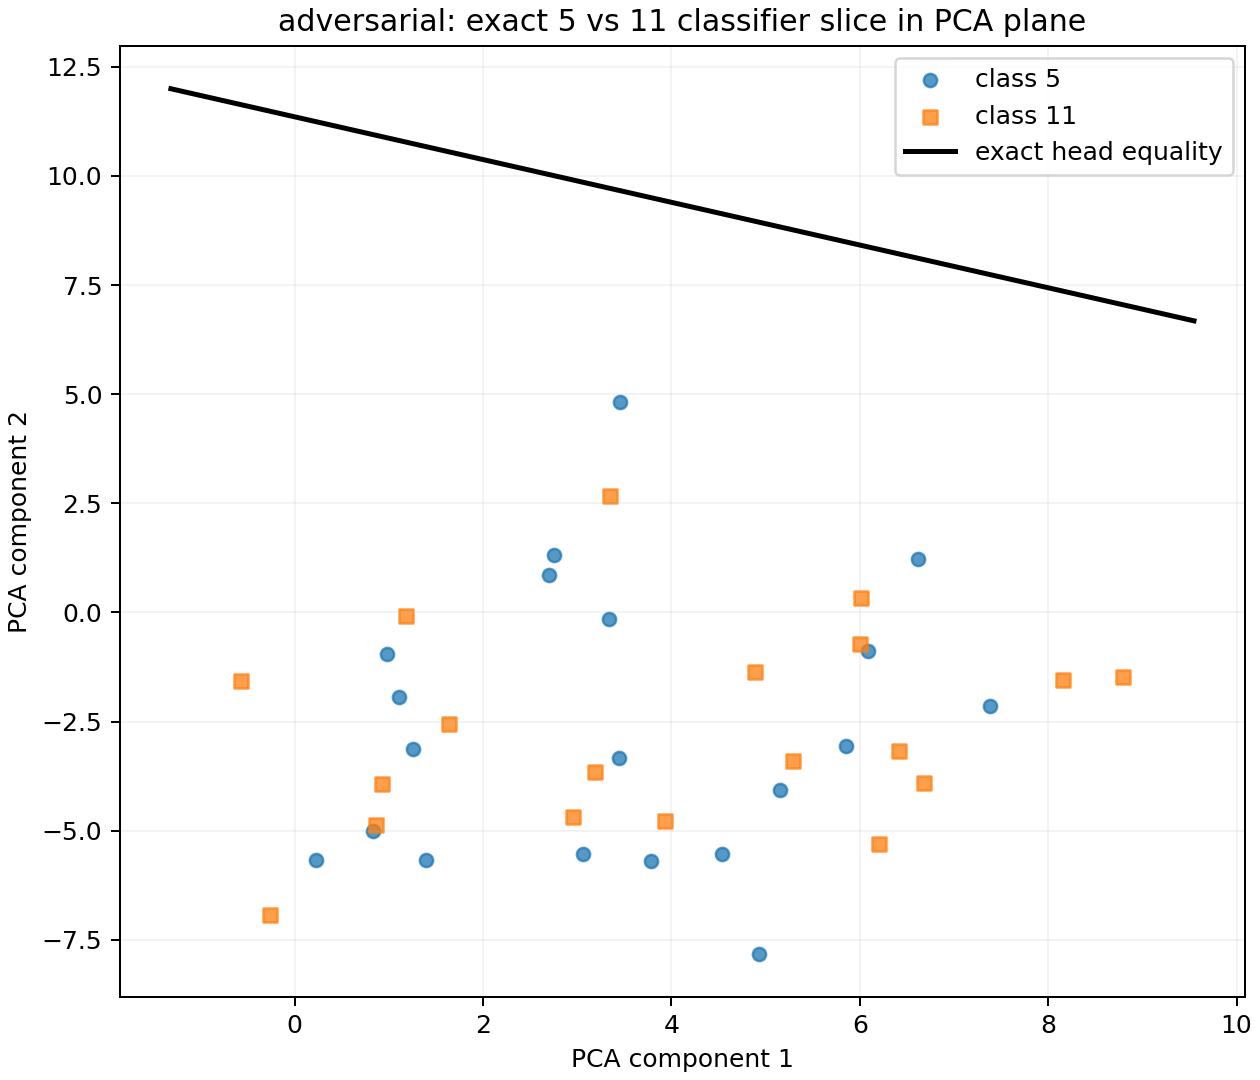 |


## 10. Calibration and selective prediction

| Clean-test policy metric | Standard | PGD-trained |
| --- | --- | --- |
| Clean calibrated coverage | 89.23% | 90.71% |
| Clean selective risk ↓ | 6.11% | 22.51% |
| Clean 15-bin ECE ↓ | 0.0224 | 0.0188 |
| Clean AURC ↓ | 0.0213 | 0.0916 |

On clean test data, the standard policy accepted 89.23% with 6.11% selective risk; the PGD-trained policy accepted 90.71% with 22.51% risk. The highest selective-risk registered shifts were `gaussian_blur-1.5` for standard fine-tuning (71.52% coverage, 17.34% risk) and `contrast-0.5` for PGD-5 fine-tuning (65.39% coverage, 68.11% risk). Both registered policy-shift checks fired. Calibration on clean inputs did not preserve the target operating point after every shift.

## 11. How to read the difficult pair

The registered tie-break selected **Bengal (class 5) and Egyptian_Mau (class 11)**. The two boundary figures show their
linear-head equality line only after restricting the 512-D representation to two PCA
coordinates and fixing all hidden coordinates at the calibration mean. A steep or distant
line can be far from the displayed point cloud because the other 510 feature directions
are fixed at their calibration mean. It does not show the full image-space boundary.

## 12. Defensible conclusion and limits

**Observation:** during this 15-epoch reference run, PGD-5 training reduced median cosine drift
from 0.4531 to
0.0378, increased five-neighbour breed
retention from 0.11% to
25.62%, and increased PGD-20×5
robust accuracy from 0.00% to
20.68%. Clean accuracy decreased from
89.15% to 72.91%.

**Interpretation:** the adversarial arm retained substantially more local and global
representation structure under this attack and gained partial prediction robustness,
while specializing away from clean and registered-corruption performance.
Representation stability and prediction robustness were related but not identical.

**Main limitation:** this is one ImageNet-initialized architecture, one split and seed
family, and one finite digital threat model. The bootstrap intervals quantify paired
test-sample uncertainty, not retraining variability. PCA, t-SNE, and UMAP remain
explanatory projections rather than evidence of intrinsic representation quality.

**Stop decision:** the registered Week 3 experiment is complete. No retraining is needed
for this release candidate. A new seed, architecture, or stronger evaluator would be a
separately registered extension rather than a repair to these results.

## 13. Evidence map

- Numerical summary: `results/generated/summary.json`
- Aggregate EDA: `results/generated/eda.json`
- Full evaluation: `results/generated/evaluation.json`
- Representation metrics: `results/generated/representations.json`
- Aggregate figures: `figures/generated/`
- Technical report: `reports/generated/technical-report.md`
- Shareable result summary: `docs/results.md`
- Shareable aggregate JSON: `docs/results.json`
- Local release manifest: `artifacts/release/local-release-manifest.json`
- Configuration SHA-256: `9e9727fe7a442e0e181349073577dca9c2e72828416c88dfe5f9d446f2ee9b14`

The notebook embeds the exact PNG bytes verified against the saved EDA, figure, and
release manifests. It contains no pet photographs and authorizes no publication.